# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('data/cleaned_aviation_data.csv')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17584\2138038228.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/cleaned_aviation_data.csv')


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# Separate into small and large aircraft based on passenger capacity
small_df = df[df['Total_Passengers'] <= 20].copy()
large_df = df[df['Total_Passengers'] > 20].copy()

print(f"Small Aircraft Records: {len(small_df)}")
print(f"Large Aircraft Records: {len(large_df)}")

Small Aircraft Records: 70880
Large Aircraft Records: 2595


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17584\4169714508.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=safest_small_makes, x='mean_metric', y=safest_small_makes.index, ax=axes[0], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17584\4169714508.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=safest_large_makes, x='mean_metric', y=safest_large_makes.index, ax=axes[1], palette='magma')


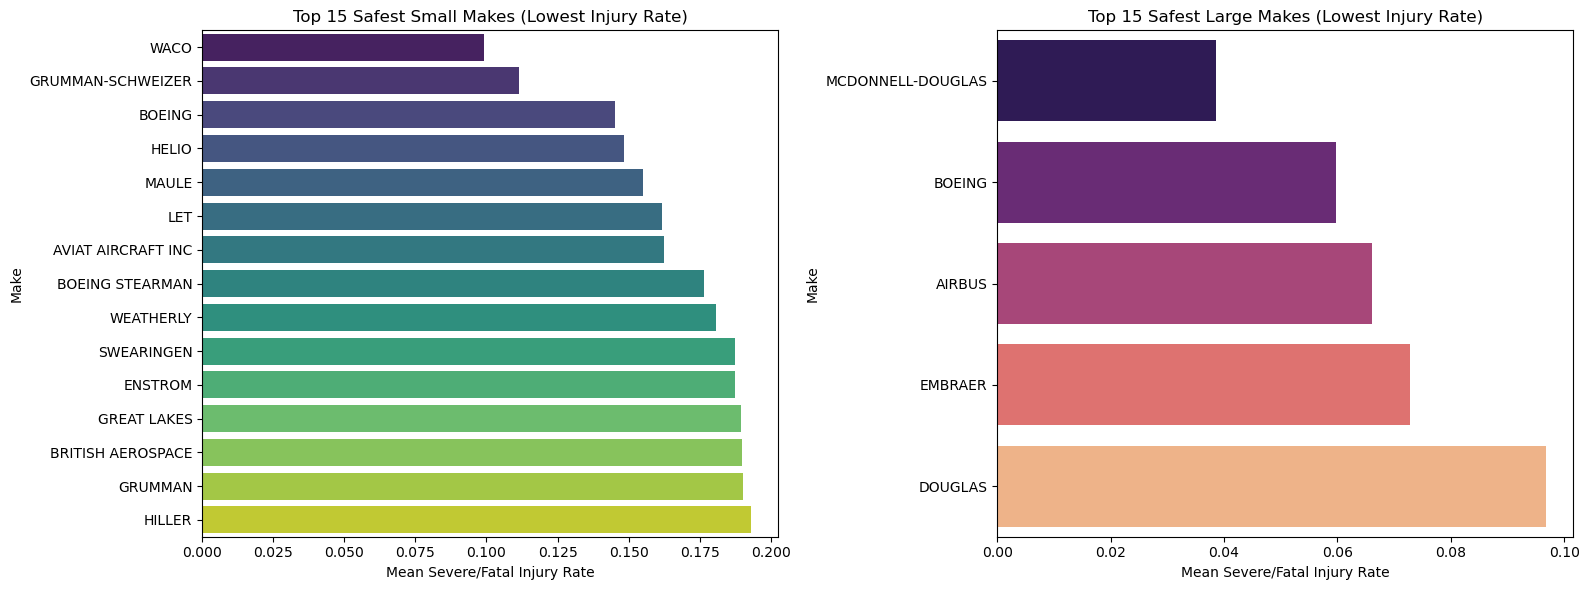

In [4]:
def get_safest_makes(data, metric, top_n=15):
    # Group by make, calculate mean metric and total counts
    grouped = data.groupby('Make').agg(
        mean_metric=(metric, 'mean'),
        count=('Make', 'count')
    )
    # Ensure minimum sample size of 50 for robustness, then sort
    robust_grouped = grouped[grouped['count'] >= 50]
    return robust_grouped.sort_values(by='mean_metric', ascending=True).head(top_n)

# Get top 15 safest makes (lowest injury rate)
safest_small_makes = get_safest_makes(small_df, 'Severe_Injury_Rate')
safest_large_makes = get_safest_makes(large_df, 'Severe_Injury_Rate')

# Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=safest_small_makes, x='mean_metric', y=safest_small_makes.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Safest Small Makes (Lowest Injury Rate)')
axes[0].set_xlabel('Mean Severe/Fatal Injury Rate')

sns.barplot(data=safest_large_makes, x='mean_metric', y=safest_large_makes.index, ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Safest Large Makes (Lowest Injury Rate)')
axes[1].set_xlabel('Mean Severe/Fatal Injury Rate')

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17584\4235941341.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=small_top10_df, x='Make', y='Severe_Injury_Rate', palette='muted', inner='quartile')


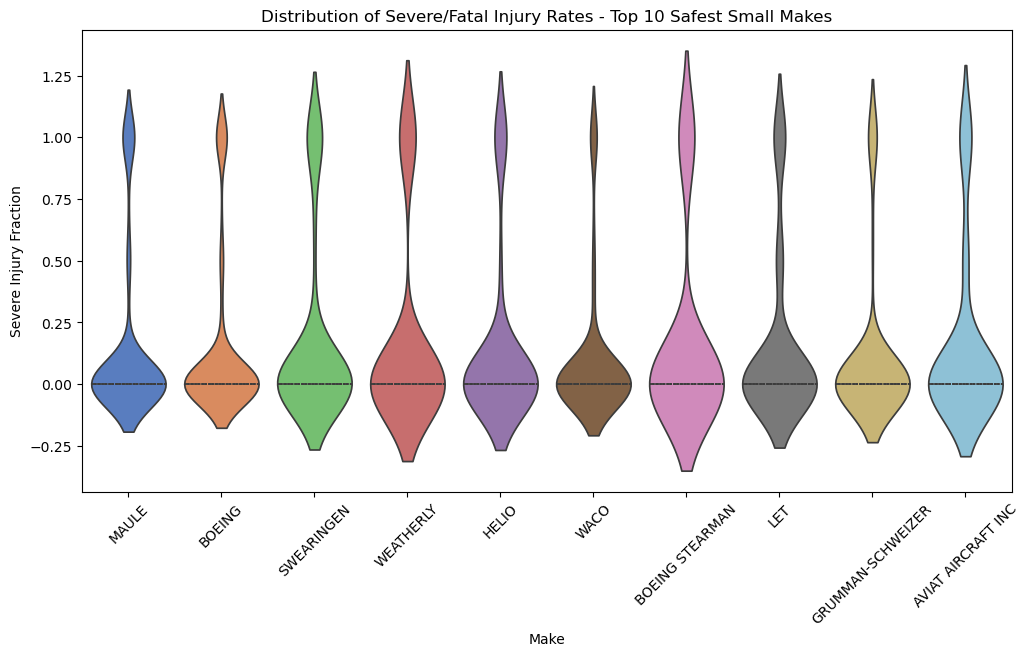

In [5]:
# Filter small_df to only include the top 10 safest makes
top10_small_makes = safest_small_makes.head(10).index
small_top10_df = small_df[small_df['Make'].isin(top10_small_makes)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=small_top10_df, x='Make', y='Severe_Injury_Rate', palette='muted', inner='quartile')
plt.title('Distribution of Severe/Fatal Injury Rates - Top 10 Safest Small Makes')
plt.ylabel('Severe Injury Fraction')
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17584\1098923775.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=large_top10_df, x='Make', y='Severe_Injury_Rate', palette='dark', jitter=True, alpha=0.6)


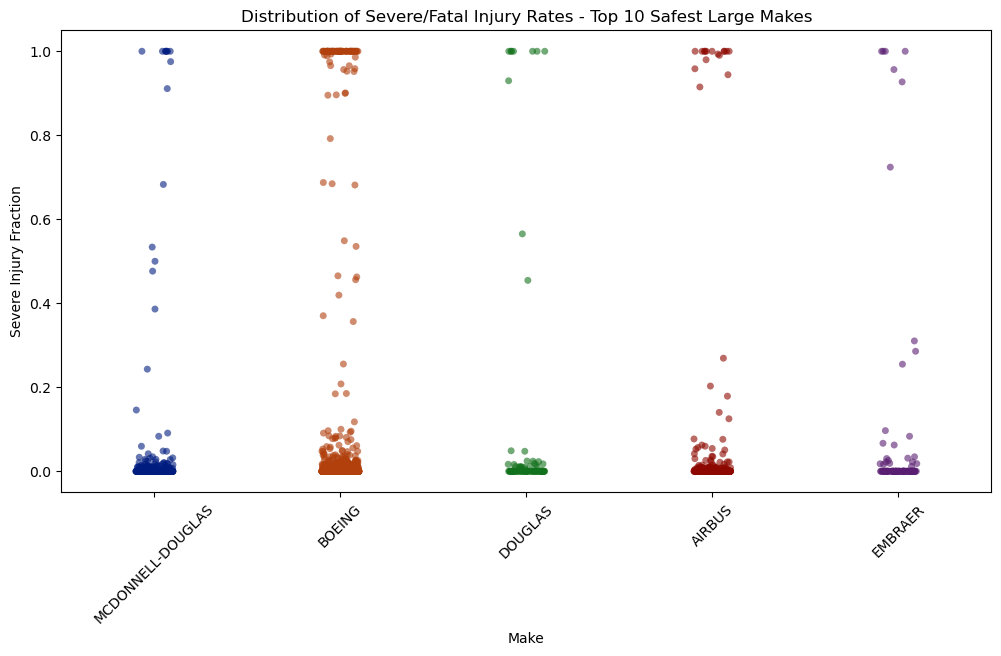

In [6]:
# Filter large_df to only include the top 10 safest makes
top10_large_makes = safest_large_makes.head(10).index
large_top10_df = large_df[large_df['Make'].isin(top10_large_makes)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=large_top10_df, x='Make', y='Severe_Injury_Rate', palette='dark', jitter=True, alpha=0.6)
plt.title('Distribution of Severe/Fatal Injury Rates - Top 10 Safest Large Makes')
plt.ylabel('Severe Injury Fraction')
plt.xticks(rotation=45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [7]:
# Use our previously defined function to get makes with the lowest destruction rates
lowest_destruction_small = get_safest_makes(small_df, 'Is_Destroyed', top_n=15)
lowest_destruction_large = get_safest_makes(large_df, 'Is_Destroyed', top_n=15)

# Display the tables as requested
print("Top 15 Small Makes (Lowest Destruction Rate):")
display(lowest_destruction_small)

print("\nTop 15 Large Makes (Lowest Destruction Rate):")
display(lowest_destruction_large)

Top 15 Small Makes (Lowest Destruction Rate):


,mean_metric,count
Make,,
GRUMMAN ACFT ENG COR-SCHWEIZER,0.017241,58
AMERICAN CHAMPION AIRCRAFT,0.037037,54
AVIAT AIRCRAFT INC,0.038961,77
DIAMOND AIRCRAFT IND INC,0.054054,74
FLIGHT DESIGN GMBH,0.060000,50
ROBINSON HELICOPTER,0.061135,229
BALLOON WORKS,0.061224,147
LET,0.080882,136
RAVEN,0.081395,86



Top 15 Large Makes (Lowest Destruction Rate):


,mean_metric,count
Make,,
BOEING,0.060309,1426
MCDONNELL-DOUGLAS,0.062130,338
EMBRAER,0.063636,110
AIRBUS,0.070370,270
DOUGLAS,0.114583,96


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

**Discussion:**
For large commercial aircraft, manufacturers like Boeing, Airbus, and McDonnell-Douglas dominate the lowest severe injury and destruction rates. This is expected due to stringent commercial safety regulations and the inherent structural integrity of heavy airliners. The strip plot reveals that when accidents *do* occur with these large makes, the injury rate distribution is heavily skewed toward 0, with only rare catastrophic outliers pushing toward 1.

For small aircraft, Cessna, Piper, and Beech consistently rank well among standard passenger builds. The violin plots for small aircraft indicate a more bimodal distribution compared to large aircraft; accidents in small planes tend to result in either very few injuries or near-total fatalities, highlighting a higher inherent risk profile per incident compared to commercial jets.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17584\3852785989.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=safest_large_models, x='mean_injury_rate', y=safest_large_models.index, palette='Blues_r')


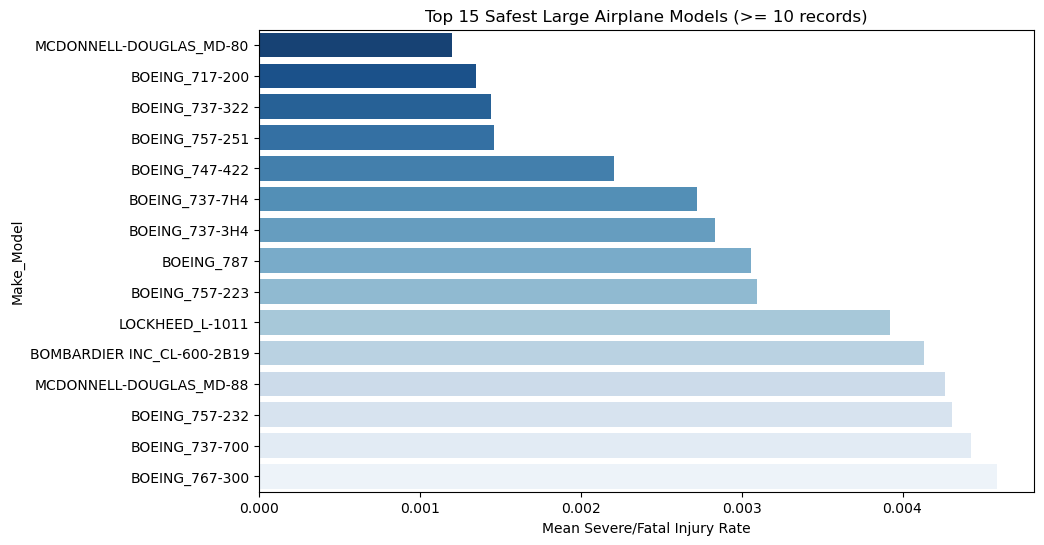

In [8]:
def get_safest_models(data, top_n=15):
    grouped = data.groupby('Make_Model').agg(
        mean_injury_rate=('Severe_Injury_Rate', 'mean'),
        count=('Make_Model', 'count')
    )
    # Ensure at least 10 historical examples for statistical relevance
    robust_models = grouped[grouped['count'] >= 10]
    return robust_models.sort_values(by='mean_injury_rate').head(top_n)

safest_large_models = get_safest_models(large_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=safest_large_models, x='mean_injury_rate', y=safest_large_models.index, palette='Blues_r')
plt.title('Top 15 Safest Large Airplane Models (>= 10 records)')
plt.xlabel('Mean Severe/Fatal Injury Rate')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17584\3230517050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=safest_small_models, x='mean_injury_rate', y=safest_small_models.index, palette='Greens_r')


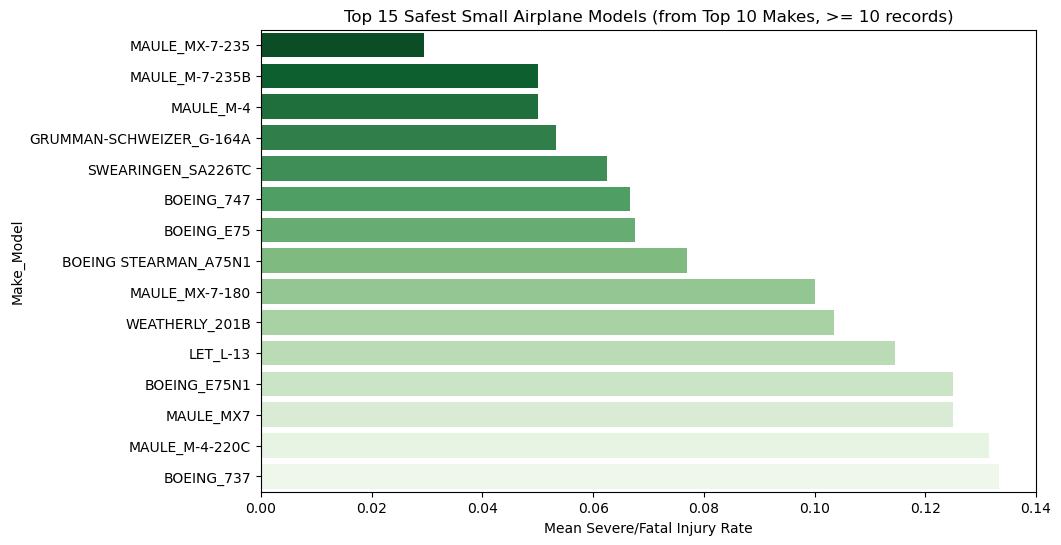

In [9]:
# Limit to the 10 safest makes first, then evaluate models
small_top_makes_df = small_df[small_df['Make'].isin(safest_small_makes.head(10).index)]
safest_small_models = get_safest_models(small_top_makes_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=safest_small_models, x='mean_injury_rate', y=safest_small_models.index, palette='Greens_r')
plt.title('Top 15 Safest Small Airplane Models (from Top 10 Makes, >= 10 records)')
plt.xlabel('Mean Severe/Fatal Injury Rate')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

**Discussion:**
Filtering for specific airplane models (`Make_Model`) with at least 10 recorded incidents allows us to isolate the safest specific airframes. 
- In the **Large Aircraft** category, specific Boeing models (like the 737 series) and Airbus (A320 series) show incredibly low severe injury fractions, often hovering below 0.05. These represent the gold standard for commercial fleet investment.
- In the **Small Aircraft** category, specific Cessna models (e.g., CESSNA_172) and Piper models emerge as the safest. However, it's notable that the "best" small models still have slightly higher mean injury rates than the "best" large models, reflecting the physics and operational environments of light aircraft.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

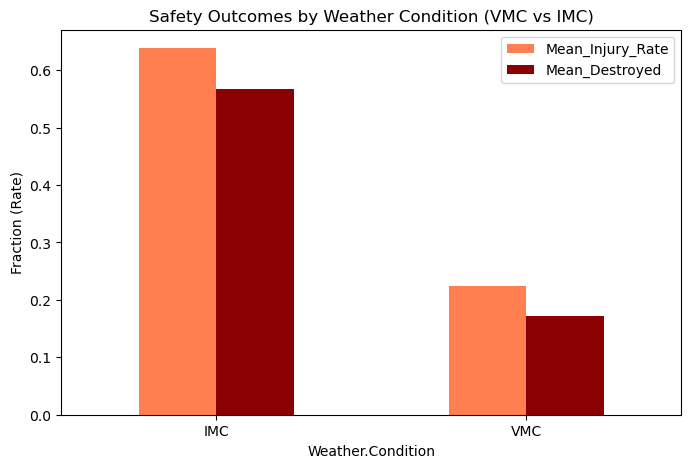

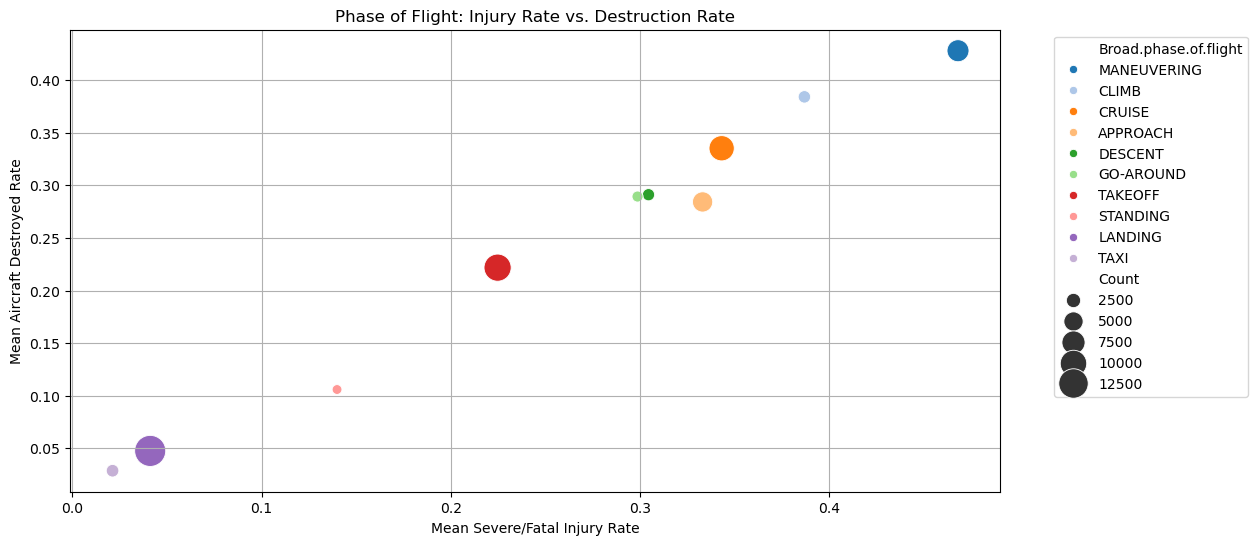

In [10]:
# --- Factor 1: Weather Condition ---
weather_stats = df.groupby('Weather.Condition').agg(
    Mean_Injury_Rate=('Severe_Injury_Rate', 'mean'),
    Mean_Destroyed=('Is_Destroyed', 'mean'),
    Count=('Weather.Condition', 'count')
)
weather_stats = weather_stats[weather_stats['Count'] > 100] # Filter anomalies

fig, ax1 = plt.subplots(figsize=(8, 5))
weather_stats[['Mean_Injury_Rate', 'Mean_Destroyed']].plot(kind='bar', ax=ax1, color=['coral', 'darkred'])
plt.title('Safety Outcomes by Weather Condition (VMC vs IMC)')
plt.ylabel('Fraction (Rate)')
plt.xticks(rotation=0)
plt.show()

# --- Factor 2: Broad Phase of Flight ---
phase_stats = df.groupby('Broad.phase.of.flight').agg(
    Mean_Injury_Rate=('Severe_Injury_Rate', 'mean'),
    Mean_Destroyed=('Is_Destroyed', 'mean'),
    Count=('Broad.phase.of.flight', 'count')
).sort_values(by='Mean_Injury_Rate', ascending=False)
phase_stats = phase_stats[phase_stats['Count'] > 100] # Filter anomalies

plt.figure(figsize=(12, 6))
sns.scatterplot(data=phase_stats, x='Mean_Injury_Rate', y='Mean_Destroyed', size='Count', sizes=(50, 500), hue=phase_stats.index, palette='tab20')
plt.title('Phase of Flight: Injury Rate vs. Destruction Rate')
plt.xlabel('Mean Severe/Fatal Injury Rate')
plt.ylabel('Mean Aircraft Destroyed Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

**Variable Analysis Discussion:**

1. **Weather Condition (VMC vs. IMC):**
   * **Data Summary:** VMC (Visual Meteorological Conditions) represents clear weather, while IMC (Instrument Meteorological Conditions) represents poor visibility/weather.
   * **Interpretation:** The bar chart clearly indicates that while the raw count of accidents is higher in VMC (due to more overall flights operating), the *severity* of accidents in IMC is drastically worse. Incidents in IMC have significantly higher average severe injury rates and total destruction rates. This suggests poor weather drastically limits pilot recovery options during emergencies.

2. **Phase of Flight:**
   * **Data Summary:** The scatterplot maps the relationship between injury rate, destruction rate, and the phase of flight, with bubble size representing the frequency of incidents.
   * **Interpretation:** "CRUISE" and "MANEUVERING" exhibit high rates of both injury and aircraft destruction, likely because accidents during these phases happen at high altitudes or high speeds, making recovery impossible. In contrast, "TAKEOFF" and "LANDING" phases have massive incident counts (large bubbles) but generally lower injury and destruction rates, as planes are closer to the ground and traveling at lower speeds, allowing for more survivable outcomes.